# Analyse des fichiers d'expérimentations

* Exécution successive (moyenne) : 10x
* CPUS : 8 CPUS-2.4 GHz
* Mémoire : 12Go

`hypothèses`:

* L'échantillonnage peut permettre d'améliorer la qualité des clusters issus de l'apprentissage par ensemble
* Combiner plusieurs algorithmes homogènes de clustering multi-vues, améliorerait la qualité des clusters

In [123]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Fine Tuning d'hyper-paramètres

chargement des resultats

In [124]:
df_mcles = pd.read_csv("results/fine_tuning.mcles.msrcv1.csv")
df_mvgl = pd.read_csv("results/fine_tuning.mvgl.msrcv1.csv")

In [125]:
metrics = ["ACC", "NMI", "PUR"]
cmaps ={ "ACC" : 'viridis' , "NMI" : 'magma', "PUR" : 'cividis' }

In [126]:
def plot_metrics(df):
    for metric in metrics:
        ax0 = plt.axes(projection="3d")

        ax0.plot_trisurf(
            df["p"],
            df["nw"],
            df[metric],
            cmap=cmaps[metric],
            edgecolor=None,
        )

        ax0.set_title(metric)
        ax0.set_xlabel("p")
        ax0.set_ylabel("nw")
        plt.show()


def pivot_tables(df, model):
    data = pd.pivot_table(df, index=["p"], columns=["nw"])
    for metric in metrics:
        data[metric].to_latex(f"./results/{metric}_{model}.tex")

### Bagging MCLES

In [127]:
df_mcles = df_mcles[["ACC", "NMI", "PUR", "p", "nw"]]
df_mcles.corr()

,ACC,NMI,PUR,p,nw
ACC,1.000000,0.231685,0.790717,-3.523301e-01,2.743776e-01
NMI,0.231685,1.000000,0.737114,7.977873e-01,1.967715e-01
PUR,0.790717,0.737114,1.000000,2.276152e-01,2.976390e-01
p,-0.352330,0.797787,0.227615,1.000000e+00,4.273250e-17
nw,0.274378,0.196771,0.297639,4.273250e-17,1.000000e+00


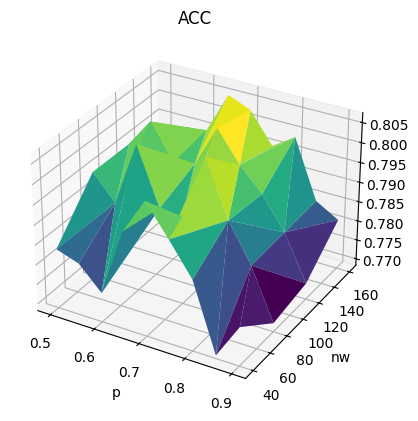

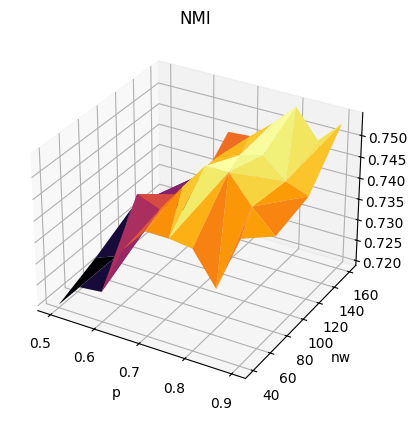

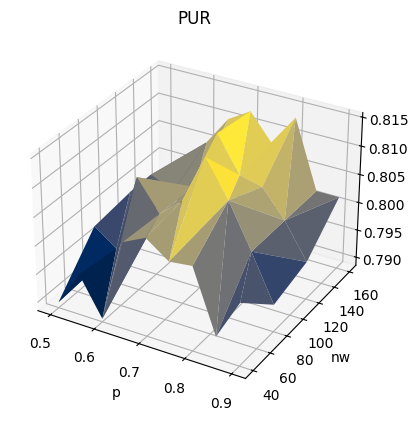

In [128]:
plot_metrics(df_mcles)

In [129]:
pivot_tables(df_mcles, "mcles")

<Axes: title={'center': 'corrélation BagMCLES'}>

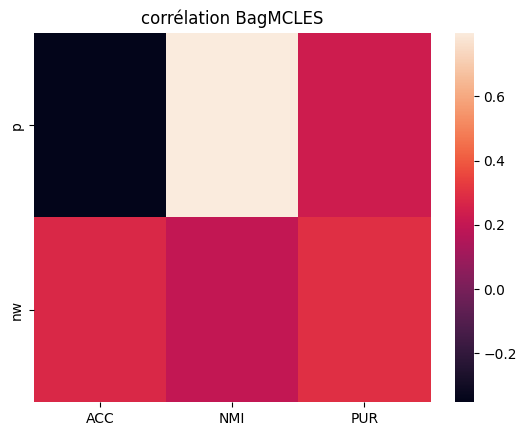

In [130]:
plt.title('corrélation BagMCLES')
sns.heatmap(df_mcles.corr()[["ACC", "NMI", "PUR"]][3:])

Nous pouvons déjà remarquer qu'on a:

* Une bonne corrélation entre la taille des échantillons et l'information mutuelle entre les clusters construits et les groupes réels
* Une faible corrélation négative entre la taille des échantillons et l'exactitude du modèle
* Une corrélation malheureusement pas très grande entre le nombre de weak-learners et la qualité des clusters construits, mais plus prononcée avec l'exactitude et la pureté


In [131]:
df_mcles.corr()[["p", "nw"]][:3].corr()

,p,nw
p,1.000000,-0.731327
nw,-0.731327,1.000000


<Axes: >

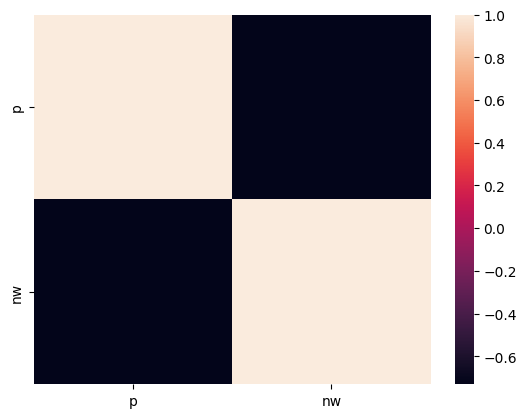

In [132]:
sns.heatmap(df_mcles.corr()[["p", "nw"]][:3].corr())

On peut aussi voir par rapport aux performances, qu'il y'a une forte corrélation négative entre la taille des échantillons et le nombre de weaks-learners utilisés

`Conclusions`

De ces remarques et des données, nous pouvons conclure que, augmenter le nombre de weak-learners et la taille des échantillons permet d'améliorer les performances du modèle.
Néanmoins puisqu'il y'a une corrélation négative entre ces deux hyper-paramètres, il faudra prioriser l'augmentation de l'un sur l'autre.

Nous pensons que donner la priorité au nombre de weak-learners est plus profitable, car il est possible d'accélérer l'exécution du modèle en le parallélisant, tout en ayant la certitude que le modèle sera plus performant.


### Bagging MVGL

In [133]:
df_mvgl = df_mvgl[["ACC", "NMI", "PUR", "p", "nw"]]
df_mvgl.corr()

,ACC,NMI,PUR,p,nw
ACC,1.000000,0.314992,0.144117,-1.835354e-01,2.181057e-01
NMI,0.314992,1.000000,-0.451029,-7.165942e-01,2.949088e-01
PUR,0.144117,-0.451029,1.000000,8.842375e-01,1.542812e-01
p,-0.183535,-0.716594,0.884238,1.000000e+00,-2.563950e-17
nw,0.218106,0.294909,0.154281,-2.563950e-17,1.000000e+00


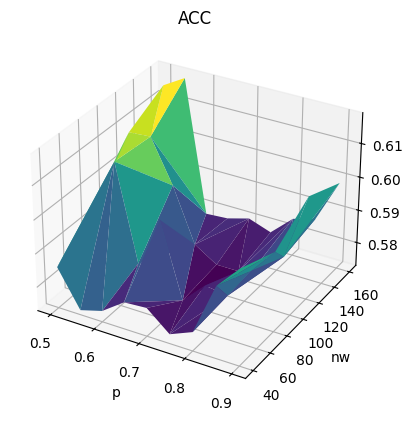

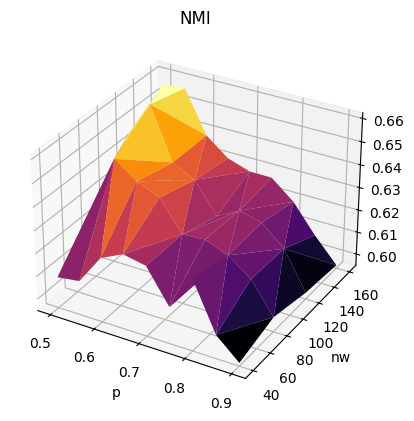

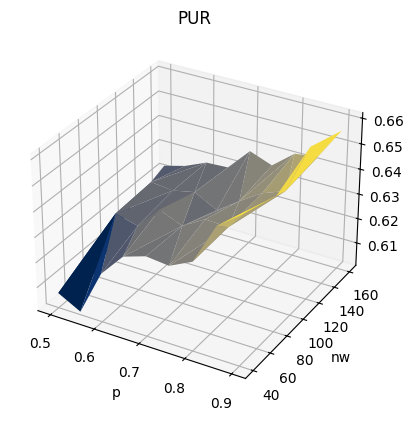

In [134]:
plot_metrics(df_mvgl)

In [135]:
pivot_tables(df_mvgl, "mvgl")

<Axes: title={'center': 'corrélation Bagging-MVGL'}>

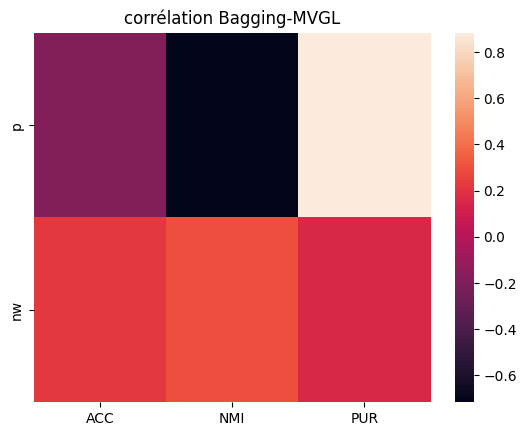

In [136]:
plt.title('corrélation Bagging-MVGL')
sns.heatmap(df_mvgl.corr()[["ACC", "NMI", "PUR"]][3:])

Nous remarquons qu'on a :
* comme pour le cas de `Bagging MCLES`, une corrélation malheureusement pas très grande entre le nombre de weak-learners et la qualité des clusters construits, mais cette fois il y'a plutôt une corrélation plus prononcée avec l'information mutuelle
* Une bonne corrélation entre la taille des échantillons et l'homogénéité des clusters construits par rapport à la réalité
* La taille des échantillons a une corrélation négative pas très forte avec l'exactitude du modèle et l'information mutuelle, néanmoins plus prononcée avec l'information mutuelle


In [137]:
df_mvgl.corr()[["p", "nw"]][:3].corr()

,p,nw
p,1.000000,-0.970441
nw,-0.970441,1.000000


<Axes: >

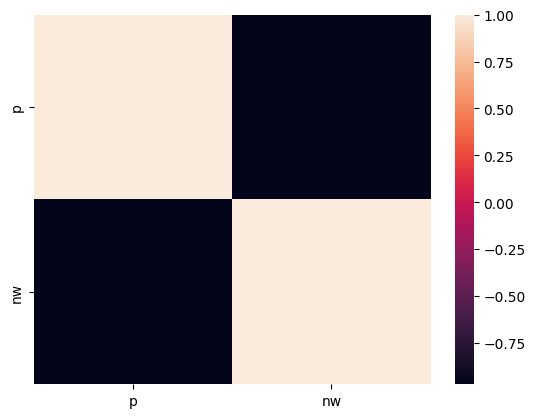

In [138]:
sns.heatmap(df_mvgl.corr()[["p", "nw"]][:3].corr())

De plus, nous avons toujours une forte corrélation négative entre ces hyper-paramètres, malgré qu'elle est plus faible.

`Conclusions`

Comme pour le cas de `Bagging MVGL`, nous avons les mêmes conclusions, à la seule différence que la priorisation à l'augmentation du nombre de clusters sera plus forte.

Celà à cause des corrélations négatives, même comme elles sont faibles, entre la taille des échantillons et les métriques d'exactitude et d'information mutuelle.

## Analyse des hyperparamètres individuellement

Au vue de l'analyse précédente, on a donné comme valeur par défaut au nombre de weak-learners à `100` (car notre ordinateur peut le supporter).

Grâce à cela on a pu faire l'analyse sur la taille des échantillons, puis l'analyse sur le nombre de weak-learners.


Fonction d'affichage de la courbe

In [139]:
def plot_progression(df, var="p"):
    fig = plt.figure()
    ax0 = fig.add_subplot(111)

    ax0.plot(df[var], df["ACC"], label="ACC")
    ax0.plot(df[var], df["NMI"], label="NMI")
    ax0.plot(df[var], df["PUR"], label="PUR")

    ax0.legend()

    if var == "p":
        ax0.set_title("Taille des échantillons")
    elif var == "nw":
        ax0.set_title("Nombre de weak-learners")

    ax0.set_xlabel(var)
    ax0.set_ylabel("metrics")

    plt.show()

Chargement des fichiers d'analyse

In [140]:
p_mcles = pd.read_csv("results/annalyse_p.mcles.msrcv1.csv").sort_values("p")
p_mvgl = pd.read_csv("results/annalyse_p.mvgl.msrcv1.csv").sort_values("p")
nw_mcles = pd.read_csv("results/annalyse_nw.mcles.msrcv1.csv").sort_values("nw")
nw_mvgl = pd.read_csv("results/annalyse_nw.mvgl.msrcv1.csv").sort_values("nw")

### Bagging MCLES

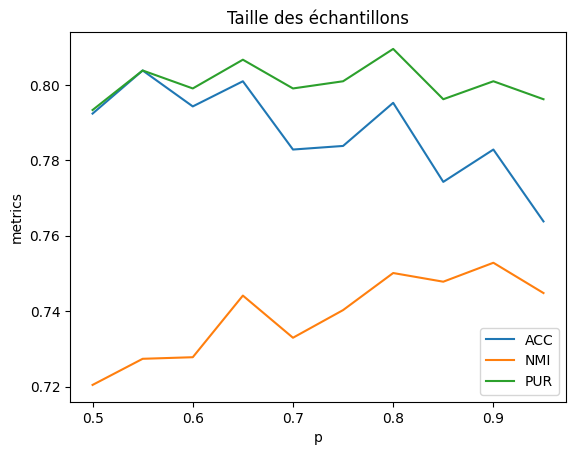

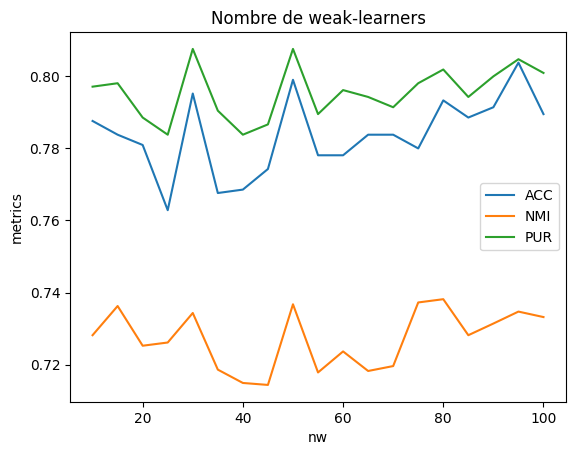

In [141]:
plot_progression(p_mcles, var="p")
plot_progression(nw_mcles, var="nw")

Ces courbes permettent de valider l'analyse qui a été faite au niveau du fine-tuning.

On peut voir que plus on augmente la taille des échantillons, plus on a tendance à avoir des clusters de moins en moins homogène, qui respectent de moins en moins la constitution des groupes réels. Néanmoins, cela augmente les informations communes avec les groupes réels.

De plus, plus on augmente le nombre de weak-learners, plus on construit les clusters homogènes respectant la constitution des groupes réels, sans pour autant augmenter les informations communes avec ces groupes.

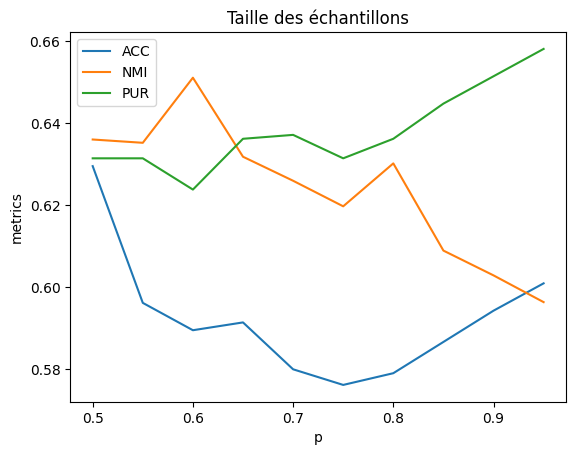

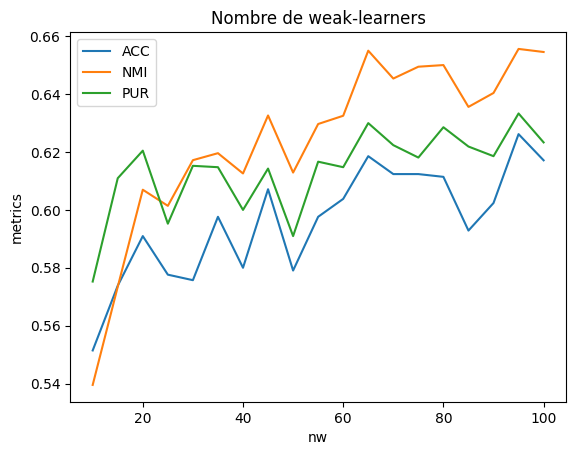

In [142]:
plot_progression(p_mvgl, var="p")
plot_progression(nw_mvgl, var="nw")

Ces courbes valident encore plus l'analyse qui a été faite au niveau du fine-tuning.

On peut voir que plus on augmente la taille des échantillons, plus on a tendance à avoir des clusters de plus en plus homogène, mais qui respecte de moins en moins la constitution des groupes réels. De plus, cela réduit la quantité d’informations communes avec ces groupes réels.

On remarque également que, plus on augmente le nombre de weak-learners, plus on construit des clusters de meilleure qualité. De plus,  la tendance d'augmentation de la qualité des clusters est plus forte que dans le cas de `Bagging-MCLES`. Ce qui nous permet déjà de valider l'hypothèse qu'avoir des modèles de base peu performants permet d'améliorer plus fortement le modèle d’apprentissage par ensemble.


## Expérimentations finales

Grâce à nos analyses précédentes, nous avons sélectionné des valeurs par défaut du modèle, pour la dataset `MSRC-V1` qui sont les suivantes

In [143]:
hyper_parametres = [
    {"model": "BagMCLES", "p": 0.6, "nw": 100},
    {"model": "BagMVGL", "p": 0.55, "nw": 100},
]

hyper_parametres = pd.DataFrame(hyper_parametres).set_index("model")
hyper_parametres.to_csv("results/hyper_parameters.csv")
hyper_parametres.to_latex("results/hyper_parameters.tex")
hyper_parametres

,p,nw
model,,
BagMCLES,0.60,100
BagMVGL,0.55,100


Ces paramètres nous ont permis de réaliser les expérimentations, dont les résultats ont été conservées

In [144]:
perfs = pd.read_csv("results/perfs.csv")

In [145]:
perfs = perfs.sort_values(["ACC", "NMI", "PUR"])[
    ["ACC", "ACC_std", "NMI", "NMI_std", "PUR", "PUR_std", "model"]
].set_index("model")
perfs

,ACC,ACC_std,NMI,NMI_std,PUR,PUR_std
model,,,,,,
mvgl,0.600000,0.000000,0.595783,0.000000,0.657143,0.000000
Bag_mvgl,0.626667,0.007127,0.667388,0.009196,0.627619,0.005553
mcles,0.720000,0.058041,0.718118,0.033318,0.755238,0.047676
Bag_mcles,0.803810,0.020293,0.733868,0.012199,0.806667,0.015238


Ce tableau nous permet de remarquer que:
* Le modèle d'apprentissage par ensemble est plus performant que les modèles de base
* Si les weak-learners sont très stables (suivant ces performances), le modèle le sera aussi mais moins fortement
* Si plutôt ils sont instables, le modèle sera encore plus stable

Cela se justifie car MCLES n'est pas très stable surtout parce qu'il utilise l'algorithme Kmeans pour construire ces clusters.
MVGL l'est bien moins vu qu'il calcule les clusters en considérant qu'ils sont des composantes connexes.

De ce fait, nous pensons qu'on pourrait également améliorer MCLES en utilisant un algorithme plus stable que Kmeans tel que GMM. On pourrait au-delà de changer Kmeans, l'introduire dans l'optimisation itérative des paramètres de MCLES, l'objectif étant d'augmenter la stabilité du modèle et les performances.

Au vue des observations, nous pouvons affirmer que l'objectif de la validation des hypothèses d'expérimentations a été atteint.

In [146]:
perfs.to_latex('results/perfs.tex')